In [19]:
#Import libraries
from typing import List, Tuple, Set
import matplotlib.pyplot as plt 
import numpy as np

In [20]:
def assign_labels(n: int):
    """
    Return:
      L1, L2, L3: Label for three levels
      seen:       edges has been seen
      number_left   egdes still not assigned
    """
    # we pre-mark '3' as already used (pre-assigned smallest "edge"),
    # so all new allocations must be >= MIN_NUM = 4.
    MIN_NUM = 4
    next_cursor = MIN_NUM

    # Profiling counters
    while_next_free = 0        # times we advanced v inside next_free()
    while_take_cursor = 0      # times we advanced next_cursor inside take()
    next_free_calls = 0        # number of next_free() calls
    retry_conflicts = 0        # times we had to retry due to conflicts
    
    def take(x: int) -> bool:
        """add value to seen weight"""
        nonlocal next_cursor,while_take_cursor
        if x in seen:
            return False
        seen.add(x)
        if x == next_cursor:
            while next_cursor in seen:
                next_cursor += 1
                while_take_cursor += 1
        return True

    def next_free(start: int = MIN_NUM) -> int:
        """ Looking for next free smallest edges"""
        nonlocal next_cursor,while_next_free, next_free_calls
        # start from max(start, next_cursor) to reduce loop
        next_free_calls += 1
        v = max(start, next_cursor, MIN_NUM)
        while v in seen:
            v += 1
            next_cursor = v
            while_next_free += 1 
        return v

    # Initially
    L1: List[int] = [2]
    L2: List[int] = []
    L3: List[int] = []
    seen: Set[int] = set()


    # Edge from the first L1 node to Z
    seen.add(3)

    # Phase 1: Build L1 and z
    for i in range(1, n): ### n
        weight = 3 * i + 2
        label = weight - L1[i - 1]

        # Assign weight for z and L1
        take(weight)
        take(label + 1)
        L1.append(label)

    # Phase 2: Build L2
    for i in range(0, n): 
        if i == 0:
            a = next_free()
            take(a)
            label = a - L1[i]
            L2.append(label)
         
        else:
            low_number = min(L2[i - 1], L1[i])
            high_number = max(L2[i - 1], L1[i])
            a = next_free()
            while True:
                label = a - low_number
                edge_val = label + high_number
                if (edge_val not in seen): 
                    take(a)
                    take(edge_val)
                    L2.append(label)
                    break
                retry_conflicts += 1  
                a = next_free(a + 1)
               


    # Phase 3: Build L3
    for i in range(0, n):
        if i == 0:
            a = next_free()
            take(a)
            label = a - L2[i]
            L3.append(label)
           
        else:
            low_number = min(L3[i - 1], L2[i])
            high_number = max(L3[i - 1], L2[i])
            a = next_free()
            while True:
                label = a - low_number
                edge_val = label + high_number
                if (edge_val not in seen):
                    take(a)
                    take(edge_val)
                    L3.append(label)
                    break
                retry_conflicts += 1  
                a = next_free(a + 1)



    # number_left: number has not been used when reaching highest bound
    if seen:
        limit = max(seen)
    else:
        limit = MIN_NUM - 1
    number_left = [v for v in range(MIN_NUM, limit + 1) if v not in seen]
    
    stats = {
        "while_next_free": while_next_free,
        "while_take_cursor": while_take_cursor,
        "next_free_calls": next_free_calls,
        "retry_conflicts": retry_conflicts,
    }

    return L1, L2, L3, seen, number_left, stats


In [21]:
# Run function
n = 5
L1, L2, L3, seen, number_left,stats = assign_labels(n)

In [22]:

## Calculating upper, lower bound and max k of the algorithms
length = 50
lower_bound = []
upper_bound = []
algorithms = []
for i in range(5, length):
    edge = (i*2) + (3*(i-1)) + i
    v = (i*3)+1
    lower_bound.append((edge+1)/2)
    upper_bound.append(edge * np.log2(v))
    L1, L2, L3, _, _,_ = assign_labels(i)
    algorithms.append(max(max(L1,L2,L3)))

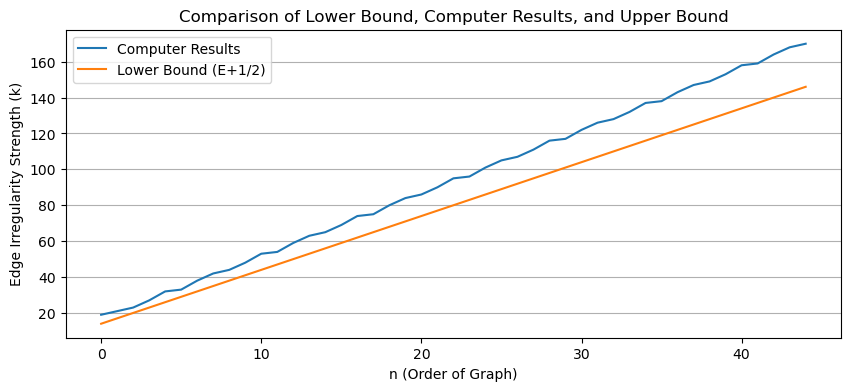

In [23]:
plt.figure(figsize=(10,4))
plt.plot(algorithms, label = 'Computer Results')
plt.plot(lower_bound, label = 'Lower Bound (E+1/2)')
# plt.plot(upper_bound, label = 'Upper Bound (Elog2V)')
plt.xlabel('n (Order of Graph)')
plt.ylabel('Edge Irregularity Strength (k)')
plt.title('Comparison of Lower Bound, Computer Results, and Upper Bound')
plt.grid(axis= 'y')
plt.legend()



In [24]:
f_lin = []
f_nlog = []
f_n2 = []
f_n2log = []
f_result = []
array = [5, 50, 500, 1000, 2000,3000,5000,7500,10000]
for n in array:
    f_lin.append(n)
    f_nlog.append(n * np.log2(n))
    f_n2.append(n**2)
    f_n2log.append((n**2) * np.log2(n))
    _, _, _, _, _, stats = assign_labels(n)
    f_result.append(n                                   # calculate time complexity 
        + stats['next_free_calls']
        + stats['while_next_free']
        + stats['while_take_cursor']
        + stats['retry_conflicts'])

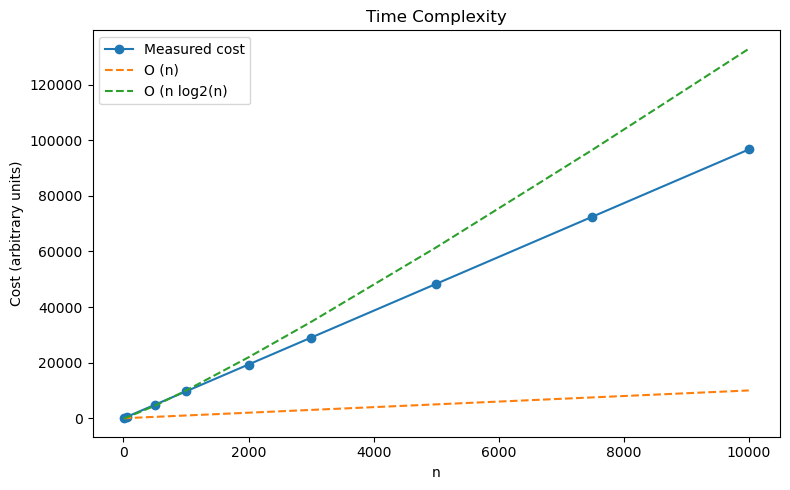

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(array, f_result, marker='o', linestyle='-', label='Measured cost')
plt.plot(array, f_lin, marker=None, linestyle='--', label='O (n)')
plt.plot(array, f_nlog, marker=None, linestyle='--', label='O (n log2(n)')
# plt.plot(array, f_n2, marker=None, linestyle='--', label='O (n^2)')
# plt.plot(array, f_n2log, marker=None, linestyle='--', label='O(n^2 log2(n))')
plt.xlabel('n')
plt.ylabel('Cost (arbitrary units)')
plt.title('Time Complexity')
plt.legend()
plt.tight_layout()
plt.show()